<a href="https://colab.research.google.com/github/GlenTarigann/Prediksi-Harga-Rumah-di-Jakarta-Selatan/blob/main/Prediksi_Harga_Rumah_Jakarta_Selatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset : https://www.kaggle.com/datasets/wisnuanggara/daftar-harga-rumah

#1. Penentuan Teknik Pemodelan: Regresi Linear Berganda
Target yang ingin diprediksi adalah nilai numerik kontinu (HARGA) yang dipengaruhi oleh lebih dari satu faktor, yaitu Luas Bangunan (LB), Luas Tanah (LT), Kamar Tidur (KT), Kamar Mandi (KM), dan Garasi (GRS). Oleh karena itu, algoritma yang digunakan adalah Regresi Linear Berganda (Multiple Linear Regression).
###Alasan:
Teknik regresi dirancang khusus untuk memprediksi nilai numerik, seperti menentukan harga rumah berdasarkan karakteristik fisik bangunan. Penggunaan varian "Berganda" memungkinkan model mengevaluasi banyak variabel independen secara serentak. Pendekatan ini menghasilkan prediksi yang jauh lebih akurat dan realistis dibandingkan regresi sederhana yang hanya mengandalkan satu fitur.
#2. Strategi Pembersihan Data (Data Cleaning)
Data mentah sering kali mengandung gangguan (noise) atau anomali yang dapat merusak performa model. Fokus utama pada tahap ini adalah menangani pencilan (outlier) pada kolom luas dan jumlah ruangan.
###Metode:
Mendeteksi outlier menggunakan batas kuartil atau Interquartile Range (IQR), lalu mengoreksinya dengan teknik clipping.
###Alasan:
Titik data yang sangat menyimpang dari pengamatan normal (outlier) terbukti dapat menurunkan akurasi model machine learning. Teknik clipping memastikan nilai ekstrem tersebut dibatasi pada batas kewajaran statistik secara otomatis, tanpa harus menghapus baris data yang berharga.
#3. Transformasi Data: Normalisasi Skala
Atribut dalam dataset memiliki rentang nilai yang sangat timpang. Sebagai contoh, Luas Tanah (LT) bisa bernilai ratusan meter persegi, sedangkan jumlah Kamar Tidur (KT) hanya berada di angka satuan.
###Metode:
Melakukan penskalaan fitur (feature scaling) menggunakan metode Normalisasi Min-Max (mengubah rentang nilai menjadi 0 hingga 1) atau Normalisasi Z-Score (berbasis rerata dan standar deviasi).
###Alasan:
Algoritma machine learning sangat sensitif terhadap perbedaan skala. Normalisasi berfungsi menyetarakan rentang nilai antar-atribut. Langkah ini memastikan fitur berskala besar (seperti luas) tidak mendominasi fitur berskala kecil (seperti jumlah kamar), sehingga seluruh variabel berkontribusi secara seimbang saat model dilatih.
#4. Skenario Pengujian (Testing Scenario)
Model tidak boleh dilatih dan diuji menggunakan data yang sama persis untuk menghindari fenomena hafalan buta (overfitting).
##Metode:
Menerapkan pembagian proporsi (percentage splitting), misalnya 80% untuk data latih dan 20% untuk data uji. Proses ini juga bisa ditingkatkan menggunakan metode Cross-validation (misalnya membagi data menjadi 5 bagian/kombinasi secara bergantian).
##Alasan:
Metode pengujian ini memastikan model yang dibangun bersifat stabil, adaptif, serta terbukti valid saat dihadapkan pada data baru yang belum pernah dipelajari sebelumnya.
#5. Pemilihan Metrik Evaluasi
Untuk mengukur seberapa jauh estimasi harga rumah meleset dari harga aslinya, diperlukan metrik pengukuran khusus untuk kasus regresi.
###Metode:
Menggunakan Mean Absolute Error (MAE) atau Root Mean Squared Error (RMSE)
###Alasan:
MAE menghitung rata-rata selisih absolut antara nilai prediksi dan harga asli. Sementara itu, RMSE memberikan bobot lebih pada error yang besar dan mengembalikan nilai kuadrat tersebut ke satuan aslinya. Kombinasi ini membuat interpretasi nominal error menjadi jauh lebih mudah dipahami, baik oleh pengembang maupun klien.

#Bab 1: Data Understanding & Cleaning

In [ ]:
import pandas as pd

# ==========================================
# 1. LOAD DATASET
# ==========================================
# Pastikan file DATA RUMAH.csv sudah di-upload ke environment Google Colab
df = pd.read_csv('DATARUMAH.csv', sep=';')

# Menghapus kolom identifier yang tidak relevan untuk analisis numerik regresi
df = df.drop(['NO', 'NAMA RUMAH'], axis=1, errors='ignore')

# ==========================================
# 2. DATA UNDERSTANDING
# ==========================================
print("--- DATA UNDERSTANDING ---")
# Identifikasi jumlah data
print("Jumlah data:", df.shape[0])

# Identifikasi tipe data
print("\nTipe data:")
print(df.dtypes)

# Identifikasi nilai yang hilang
print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Deskripsi statistik data[cite: 1]
print("\nDeskripsi statistik sebelum pembersihan:")
print(df.describe())

# ==========================================
# 3. DATA CLEANING
# ==========================================
print("\n--- DATA CLEANING ---")
# Identifikasi outlier menggunakan IQR[cite: 1]
fitur_numerik = ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']

for column in fitur_numerik:
    # Menghitung kuartil bawah (Q1) dan kuartil atas (Q3)[cite: 1]
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan batas atas toleransi normal[cite: 1]
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mendeteksi jumlah outlier[cite: 1]
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Jumlah outlier terdeteksi pada kolom {column}: {len(outliers)}")

    # Mengoreksi nilai outlier dengan clipping[cite: 1]
    df[column] = df[column].clip(lower_bound, upper_bound)

# Deskripsi statistik setelah pembersihan[cite: 1]
print("\nDeskripsi statistik setelah pembersihan outlier:")
print(df.describe())

--- DATA UNDERSTANDING ---
Jumlah data: 1010

Tipe data:
HARGA    int64
LB       int64
LT       int64
KT       int64
KM       int64
GRS      int64
dtype: object

Jumlah nilai yang hilang:
HARGA    0
LB       0
LT       0
KT       0
KM       0
GRS      0
dtype: int64

Deskripsi statistik sebelum pembersihan:
              HARGA           LB           LT           KT           KM  \
count  1.010000e+03  1010.000000  1010.000000  1010.000000  1010.000000   
mean   7.628987e+09   276.539604   237.432673     4.668317     3.607921   
std    7.340946e+09   177.864557   179.957604     1.572776     1.420066   
min    4.300000e+08    40.000000    25.000000     2.000000     1.000000   
25%    3.262500e+09   150.000000   130.000000     4.000000     3.000000   
50%    5.000000e+09   216.500000   165.000000     4.000000     3.000000   
75%    9.000000e+09   350.000000   290.000000     5.000000     4.000000   
max    6.500000e+10  1126.000000  1400.000000    10.000000    10.000000   

               

#Bab 2: Transformasi Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("--- TRANSFORMASI DATA ---")

# 1. Pemisahan Variabel Independen (X) dan Variabel Dependen (y)
# Sesuai materi, y = target prediksi (HARGA), dan X = variabel prediktor
X = df[['LB', 'LT', 'KT', 'KM', 'GRS']]
y = df['HARGA']

print("5 Baris pertama Variabel Independen (X) SEBELUM normalisasi:")
print(X.head())

# 2. Inisialisasi metode MinMaxScaler
scaler = MinMaxScaler()

# 3. Menerapkan transformasi/normalisasi pada variabel independen (X)
X_scaled = scaler.fit_transform(X)

# Mengonversi kembali array hasil transformasi menjadi DataFrame agar mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=['LB', 'LT', 'KT', 'KM', 'GRS'])

print("\n5 Baris pertama Variabel Independen (X) SETELAH normalisasi (Min-Max 0-1):")
print(X_scaled_df.head())

print("\nDeskripsi statistik X setelah normalisasi (Perhatikan nilai min=0 dan max=1):")
print(X_scaled_df.describe())

--- TRANSFORMASI DATA ---
5 Baris pertama Variabel Independen (X) SEBELUM normalisasi:
    LB   LT   KT   KM  GRS
0  220  220  3.0  3.0  0.0
1  180  137  4.0  3.0  2.0
2  267  250  4.0  4.0  3.5
3   40   25  2.5  2.0  0.0
4  400  355  6.0  5.0  3.0

5 Baris pertama Variabel Independen (X) SETELAH normalisasi (Min-Max 0-1):
         LB        LT     KT     KM       GRS
0  0.295082  0.386139  0.125  0.375  0.000000
1  0.229508  0.221782  0.375  0.375  0.571429
2  0.372131  0.445545  0.375  0.625  1.000000
3  0.000000  0.000000  0.000  0.125  0.000000
4  0.590164  0.653465  0.875  0.875  0.857143

Deskripsi statistik X setelah normalisasi (Perhatikan nilai min=0 dan max=1):
                LB           LT           KT           KM          GRS
count  1010.000000  1010.000000  1010.000000  1010.000000  1010.000000
mean      0.373032     0.391552     0.503342     0.503094     0.498303
std       0.246434     0.269748     0.295539     0.280597     0.303441
min       0.000000     0.000000     

#Bab 3: Skenario Pengujian dan Pembangunan Model Regresi

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("--- SKENARIO PENGUJIAN & PEMODELAN ---")

# 1. Skenario Pengujian: Membagi data latih (80%) dan data uji (20%)
# X_scaled_df adalah data atribut (LB, LT, KT, dll) yang sudah dinormalisasi dari bab sebelumnya
# y adalah target prediksi (HARGA) yang tidak dinormalisasi
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih (untuk belajar): {X_train.shape[0]} baris")
print(f"Jumlah data uji (untuk evaluasi): {X_test.shape[0]} baris")

# 2. Inisialisasi Model Regresi Linear Berganda
model_regresi = LinearRegression()

# 3. Melatih Model (Training) menggunakan data latih
print("\nMelatih model Regresi Linear Berganda...")
model_regresi.fit(X_train, y_train)

# 4. Melakukan Prediksi (Testing) menggunakan data uji
y_pred = model_regresi.predict(X_test)

# ==========================================
# 4. EVALUASI MODEL
# ==========================================
print("\n--- EVALUASI MODEL ---")

# Menghitung Mean Absolute Error (MAE)
# Menunjukkan rata-rata tebakan model meleset berapa Rupiah secara absolut
mae = mean_absolute_error(y_test, y_pred)

# Menghitung Mean Squared Error (MSE) & Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

# Menampilkan 5 perbandingan harga aktual vs harga tebakan model
df_hasil = pd.DataFrame({'Harga Aktual': y_test, 'Harga Prediksi': y_pred})
print("\nPerbandingan 5 Data Pertama (Harga Aktual vs Prediksi):")
print(df_hasil.head())

--- SKENARIO PENGUJIAN & PEMODELAN ---
Jumlah data latih (untuk belajar): 808 baris
Jumlah data uji (untuk evaluasi): 202 baris

Melatih model Regresi Linear Berganda...

--- EVALUASI MODEL ---
Mean Absolute Error (MAE): 1,355,109,371.62
Root Mean Squared Error (RMSE): 1,920,356,814.36

Perbandingan 5 Data Pertama (Harga Aktual vs Prediksi):
     Harga Aktual  Harga Prediksi
629    8900000000    9.086693e+09
788    6500000000    4.700388e+09
684    6500000000    7.098235e+09
516   17606250000    1.649943e+10
529   17606250000    1.481231e+10


#Bab 4: Visualisasi Hasil dan Penyimpanan Model (Export)

--- VISUALISASI HASIL PREDIKSI ---


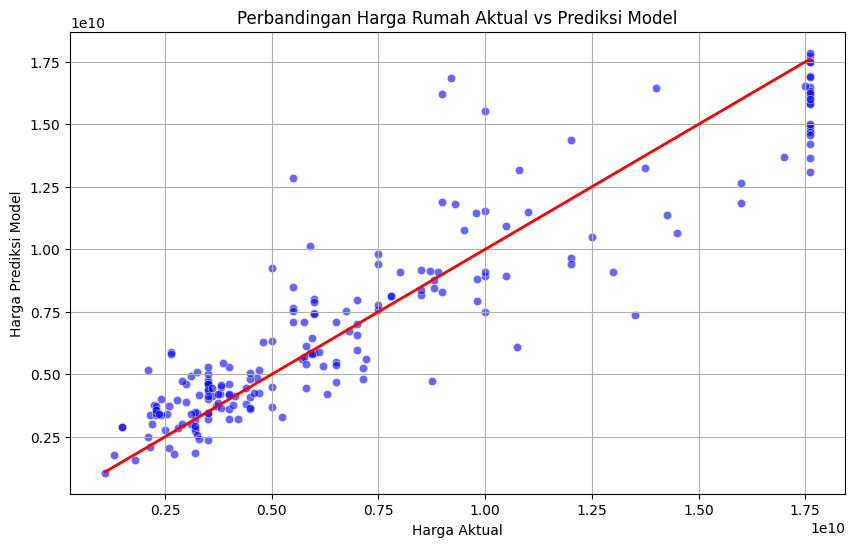


--- EXPORT MODEL & SCALER UNTUK DEPLOYMENT ---
File 'model_regresi_jaksel.pkl' dan 'scaler_jaksel.pkl' berhasil disimpan!
Silakan unduh kedua file tersebut dari panel 'Files' Google Colab di menu sebelah kiri.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("--- VISUALISASI HASIL PREDIKSI ---")
# 1. Visualisasi Scatter Plot (Harga Aktual vs Harga Prediksi)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)

# Menambahkan garis diagonal referensi (jika prediksi sempurna, semua titik akan berada di garis ini)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.title('Perbandingan Harga Rumah Aktual vs Prediksi Model')
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi Model')
plt.grid(True)
plt.show()

print("\n--- EXPORT MODEL & SCALER UNTUK DEPLOYMENT ---")
# 2. Menyimpan model regresi dan scaler menggunakan joblib
# Scaler wajib disimpan agar data input baru dari pengguna di dashboard bisa dinormalisasi dengan skala yang sama
joblib.dump(model_regresi, 'model_regresi_jaksel.pkl')
joblib.dump(scaler, 'scaler_jaksel.pkl')

print("File 'model_regresi_jaksel.pkl' dan 'scaler_jaksel.pkl' berhasil disimpan!")
print("Silakan unduh kedua file tersebut dari panel 'Files' Google Colab di menu sebelah kiri.")